# Interpolación de la figura de Snoopy

**Métodos Numéricos · Tarea 2**

Se interpola el contorno de Snoopy con tres métodos: **Vandermonde**, **Lagrange** y **spline cúbico sujeto** (programado a mano y validado contra SciPy).

El contorno se divide en tres curvas, cada una interpolada por separado. Contenido:

1. Datos
2. Interpolante de Vandermonde
3. Interpolante de Lagrange
4. Spline cúbico sujeto (con validación)
5. Comparación de los métodos
6. Silueta completa de Snoopy

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

%matplotlib inline

GUARDAR = False      # True: guarda las figuras en PDF dentro de la carpeta figuras/
NMALLA = 400         # puntos de la malla de evaluación en cada curva
YLIM = (0, 9)        # el eje vertical se recorta entre 0 y 9

if GUARDAR:
    os.makedirs("figuras", exist_ok=True)

## 1. Datos

Nodos $x_i$, valores $f(x_i)$ y derivadas $f'$ en el primer y el último nodo de cada curva.

In [2]:
curvas = [
    dict(x=[1, 2, 5, 6, 7, 8, 10, 13, 17],
         y=[3.0, 3.7, 3.9, 4.2, 5.7, 6.6, 7.1, 6.7, 4.5], d0=1.0,  dn=-0.67),
    dict(x=[17, 20, 23, 24, 25, 27, 27.7],
         y=[4.5, 7.0, 6.1, 5.6, 5.8, 5.2, 4.1],           d0=3.0,  dn=-4.0),
    dict(x=[27.7, 28, 29, 30],
         y=[4.1, 4.3, 4.1, 3.0],                          d0=0.33, dn=-1.5),
]

datos = []
for c in curvas:
    x, y = np.array(c["x"], float), np.array(c["y"], float)
    datos.append(dict(x=x, y=y, d0=c["d0"], dn=c["dn"],
                      t=np.linspace(x[0], x[-1], NMALLA)))

for k, c in enumerate(curvas, start=1):
    der = [""] * len(c["x"])
    der[0], der[-1] = str(c["d0"]), str(c["dn"])
    df = pd.DataFrame({"x_i": c["x"], "f(x_i)": c["y"], "f'(x_i)": der})
    print(f"Curva {k}  (n = {len(c['x']) - 1})")
    display(df)

Curva 1  (n = 8)


,x_i,f(x_i),f'(x_i)
0,1,3.0,1.0
1,2,3.7,
2,5,3.9,
3,6,4.2,
4,7,5.7,
5,8,6.6,
6,10,7.1,
7,13,6.7,
8,17,4.5,-0.67


Curva 2  (n = 6)


,x_i,f(x_i),f'(x_i)
0,17.0,4.5,3.0
1,20.0,7.0,
2,23.0,6.1,
3,24.0,5.6,
4,25.0,5.8,
5,27.0,5.2,
6,27.7,4.1,-4.0


Curva 3  (n = 3)


,x_i,f(x_i),f'(x_i)
0,27.7,4.1,0.33
1,28.0,4.3,
2,29.0,4.1,
3,30.0,3.0,-1.5


In [3]:
def graficar_metodo(nombre, funcs, archivo=None):
    # Dibuja las tres curvas interpoladas con un mismo método.
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
    for k, (ax, d, f) in enumerate(zip(axs, datos, funcs), start=1):
        ax.plot(d["t"], f(d["t"]), "b-")
        ax.plot(d["x"], d["y"], "ro", ms=4)
        ax.set(title=f"Curva {k}: {nombre}", xlabel="x", ylim=YLIM)
        ax.grid(alpha=.3)
    axs[0].set_ylabel("f(x)")
    fig.tight_layout()
    if GUARDAR and archivo:
        fig.savefig(f"figuras/{archivo}.pdf")
    plt.show()

## 2. Interpolante de Vandermonde

Se busca $P(x)=a_0+a_1x+\dots+a_nx^n$ con $P(x_i)=y_i$, lo que da el sistema $V\mathbf{a}=\mathbf{y}$ con $V_{ij}=x_i^{\,j}$.
Se resuelve con `numpy.linalg.solve`. También se calcula $\mathrm{cond}(V)$, que indica cuánto pueden amplificarse los errores de redondeo en los coeficientes.

Curva 1: grado 8, cond(V) = 3.324e+12
   coeficientes a_0..a_n: [ 4.9521e+01 -1.0427e+02  8.4633e+01 -3.3235e+01  7.1919e+00 -9.0163e-01
  6.5104e-02 -2.5054e-03  3.9661e-05]
Curva 2: grado 6, cond(V) = 4.479e+14
   coeficientes a_0..a_n: [ 1.2431e+05 -3.2962e+04  3.6148e+03 -2.0993e+02  6.8110e+00 -1.1709e-01
  8.3344e-04]
Curva 3: grado 3, cond(V) = 2.481e+09
   coeficientes a_0..a_n: [-2.6503e+03  2.6303e+02 -8.6457e+00  9.4203e-02]


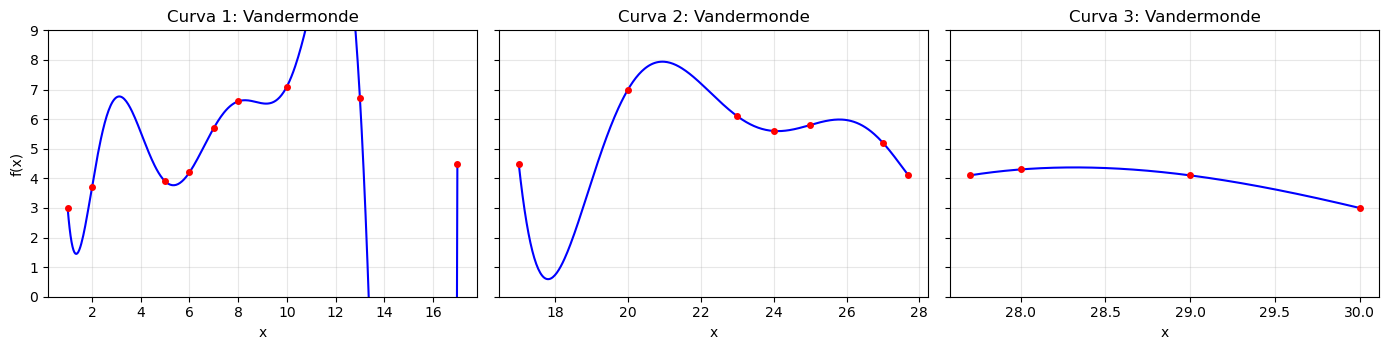

In [4]:
def vandermonde(x, y):
    V = np.vander(x, increasing=True)          # columnas 1, x, x^2, ...
    a = np.linalg.solve(V, y)                  # coeficientes a_0 ... a_n
    P = lambda t: np.polynomial.polynomial.polyval(t, a)
    return P, a, np.linalg.cond(V)

vand = [vandermonde(d["x"], d["y"]) for d in datos]
PV = [v[0] for v in vand]

for k, (P, a, cond) in enumerate(vand, start=1):
    print(f"Curva {k}: grado {len(a) - 1}, cond(V) = {cond:.3e}")
    print("   coeficientes a_0..a_n:", np.array2string(a, precision=4))

graficar_metodo("Vandermonde", PV)

## 3. Interpolante de Lagrange

Se construyen directamente los polinomios de la base,
$L_i(x)=\prod_{j\neq i}\dfrac{x-x_j}{x_i-x_j}$, y el interpolante es $P(x)=\sum_i y_i L_i(x)$. No se resuelve ningún sistema.

Curva 1: max|P(x_i) - y_i| = 0.00e+00
Curva 2: max|P(x_i) - y_i| = 0.00e+00
Curva 3: max|P(x_i) - y_i| = 0.00e+00


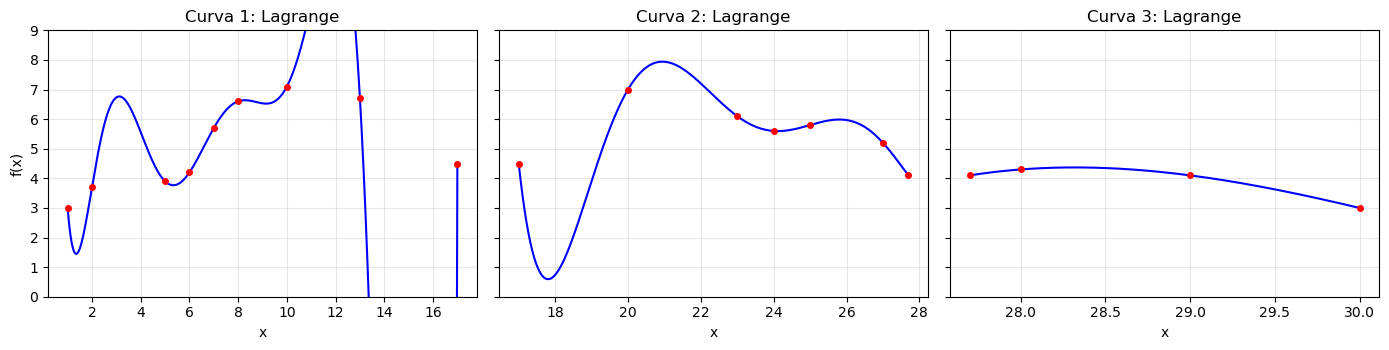

In [5]:
def lagrange(x, y):
    def P(t):
        t = np.asarray(t, float)
        total = np.zeros_like(t)
        for i in range(len(x)):
            Li = np.ones_like(t)
            for j in range(len(x)):
                if j != i:
                    Li *= (t - x[j]) / (x[i] - x[j])
            total += y[i] * Li
        return total
    return P

PL = [lagrange(d["x"], d["y"]) for d in datos]

for k, (d, P) in enumerate(zip(datos, PL), start=1):
    print(f"Curva {k}: max|P(x_i) - y_i| = {np.max(np.abs(P(d['x']) - d['y'])):.2e}")

graficar_metodo("Lagrange", PL)

## 4. Spline cúbico sujeto

En cada subintervalo $[x_i,x_{i+1}]$ se usa $S_i(x)=a_i+b_i(x-x_i)+c_i(x-x_i)^2+d_i(x-x_i)^3$, con continuidad de $S$, $S'$ y $S''$ y las condiciones de frontera $S'(x_0)=f'(x_0)$, $S'(x_n)=f'(x_n)$.

Los coeficientes $c_i$ salen de un sistema **tridiagonal**, que se resuelve con el algoritmo de Thomas en $O(n)$. Después se calculan $b_i$ y $d_i$.

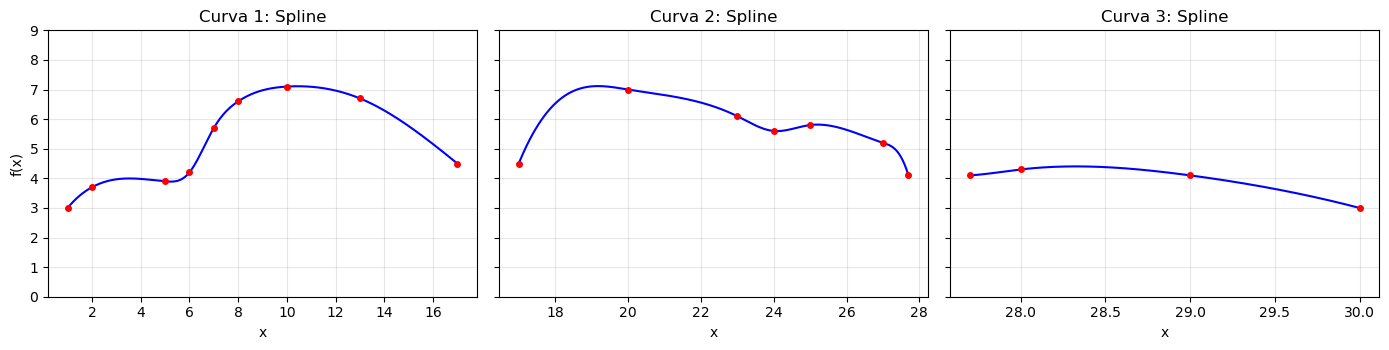

In [6]:
def tridiagonal(inf, diag, sup, r):
    # Algoritmo de Thomas para un sistema tridiagonal, O(n).
    n = len(diag)
    u = np.zeros(n); g = np.zeros(n); z = np.zeros(n)
    u[0] = diag[0]; g[0] = sup[0] / u[0]; z[0] = r[0] / u[0]
    for i in range(1, n):
        u[i] = diag[i] - inf[i - 1] * g[i - 1]
        if i < n - 1:
            g[i] = sup[i] / u[i]
        z[i] = (r[i] - inf[i - 1] * z[i - 1]) / u[i]
    c = np.zeros(n)
    c[-1] = z[-1]
    for i in range(n - 2, -1, -1):
        c[i] = z[i] - g[i] * c[i + 1]
    return c


def spline_sujeto(x, y, d0, dn):
    a = np.array(y, float)
    n = len(x) - 1
    h = np.diff(x)
    diag = np.zeros(n + 1); inf = np.zeros(n); sup = np.zeros(n); r = np.zeros(n + 1)
    diag[0] = 2 * h[0]; sup[0] = h[0]
    r[0] = 3 * (a[1] - a[0]) / h[0] - 3 * d0
    for i in range(1, n):
        inf[i - 1] = h[i - 1]
        diag[i] = 2 * (h[i - 1] + h[i])
        sup[i] = h[i]
        r[i] = 3 * (a[i + 1] - a[i]) / h[i] - 3 * (a[i] - a[i - 1]) / h[i - 1]
    inf[n - 1] = h[n - 1]; diag[n] = 2 * h[n - 1]
    r[n] = 3 * dn - 3 * (a[n] - a[n - 1]) / h[n - 1]
    c = tridiagonal(inf, diag, sup, r)
    b = (a[1:] - a[:-1]) / h - h * (2 * c[:-1] + c[1:]) / 3
    d = (c[1:] - c[:-1]) / (3 * h)

    def S(t):
        t = np.asarray(t, float)
        i = np.clip(np.searchsorted(x, t, side="right") - 1, 0, n - 1)
        dx = t - x[i]
        return a[i] + b[i] * dx + c[i] * dx**2 + d[i] * dx**3
    return S

S = [spline_sujeto(d["x"], d["y"], d["d0"], d["dn"]) for d in datos]
graficar_metodo("Spline", S)

### Validación contra SciPy

Se compara el spline programado con `scipy.interpolate.CubicSpline`, usando `bc_type=((1, f'(x_0)), (1, f'(x_n)))`, que es la misma condición de frontera.

In [7]:
filas = []
for k, (d, s) in enumerate(zip(datos, S), start=1):
    ref = CubicSpline(d["x"], d["y"], bc_type=((1, d["d0"]), (1, d["dn"])))
    filas.append({"Curva": k,
                  "max|S - SciPy|": np.max(np.abs(s(d["t"]) - ref(d["t"]))),
                  "error en los nodos": np.max(np.abs(s(d["x"]) - d["y"])),
                  "error de S'(x_0)": abs(float(ref(d["x"][0], 1)) - d["d0"])})
pd.DataFrame(filas).set_index("Curva").map(lambda v: f"{v:.2e}")

,max|S - SciPy|,error en los nodos,error de S'(x_0)
Curva,,,
1,1.78e-15,0.00e+00,0.00e+00
2,1.78e-15,0.00e+00,0.00e+00
3,8.88e-16,4.44e-16,0.00e+00


## 5. Comparación de los métodos

Como $f$ no se conoce fuera de los nodos, la comparación usa:
condicionamiento de $V$, diferencia entre Vandermonde y Lagrange (teóricamente el mismo polinomio), error en los nodos y oscilación entre nodos (mínimo y máximo del interpolante frente al rango de los datos).

In [8]:
met = {"Vandermonde": PV, "Lagrange": PL, "Spline": S}

resumen = []
for k, d in enumerate(datos):
    t = d["t"]
    resumen.append({"Curva": k + 1, "n": len(d["x"]) - 1,
                    "cond(V)": vand[k][2],
                    "max|P_V - P_L|": np.max(np.abs(PV[k](t) - PL[k](t)))})
print("Vandermonde frente a Lagrange")
display(pd.DataFrame(resumen).set_index("Curva").map(lambda v: f"{v:.2e}" if isinstance(v, float) else v))

filas = []
for k, d in enumerate(datos, start=1):
    for m, funcs in met.items():
        f = funcs[k - 1]
        filas.append({"Curva": k, "Método": m,
                      "error en los nodos": f"{np.max(np.abs(f(d['x']) - d['y'])):.2e}",
                      "mínimo": round(float(f(d["t"]).min()), 2),
                      "máximo": round(float(f(d["t"]).max()), 2),
                      "rango de los datos": f"[{d['y'].min():.2f}, {d['y'].max():.2f}]"})
print("Error en los nodos y oscilación entre nodos")
display(pd.DataFrame(filas).set_index(["Curva", "Método"]))

Vandermonde frente a Lagrange


,n,cond(V),max|P_V - P_L|
Curva,,,
1,8,3.32e+12,3.14e-10
2,6,4.48e+14,2.09e-09
3,3,2.48e+09,1.51e-12


Error en los nodos y oscilación entre nodos


error en los nodos  mínimo  máximo rango de los datos
Curva Método                                                           
1     Vandermonde           1.60e-10 -109.04   12.56       [3.00, 7.10]
      Lagrange              0.00e+00 -109.04   12.56       [3.00, 7.10]
      Spline                0.00e+00    3.00    7.11       [3.00, 7.10]
2     Vandermonde           6.29e-10    0.59    7.94       [4.10, 7.00]
      Lagrange              0.00e+00    0.59    7.94       [4.10, 7.00]
      Spline                0.00e+00    4.10    7.12       [4.10, 7.00]
3     Vandermonde           9.09e-13    3.00    4.37       [3.00, 4.30]
      Lagrange              0.00e+00    3.00    4.37       [3.00, 4.30]
      Spline                4.44e-16    3.00    4.40       [3.00, 4.30]

### Los tres métodos en cada curva

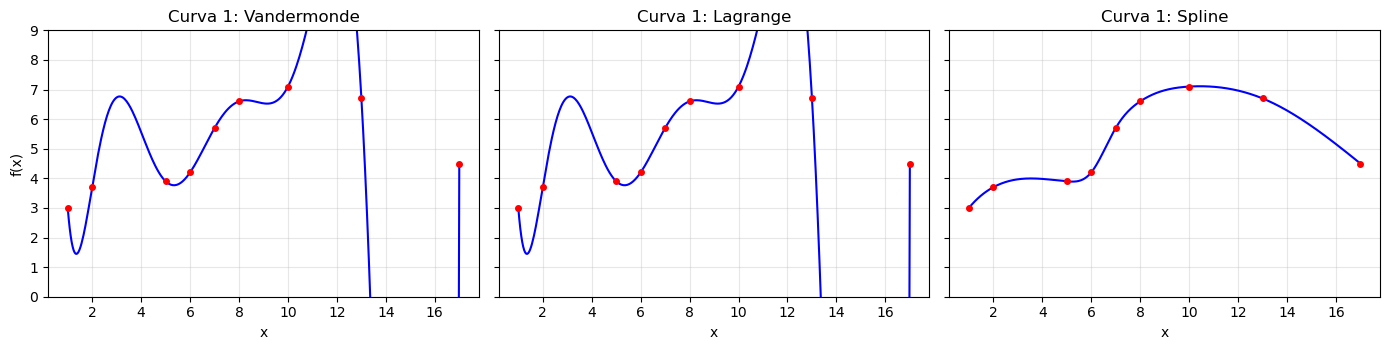

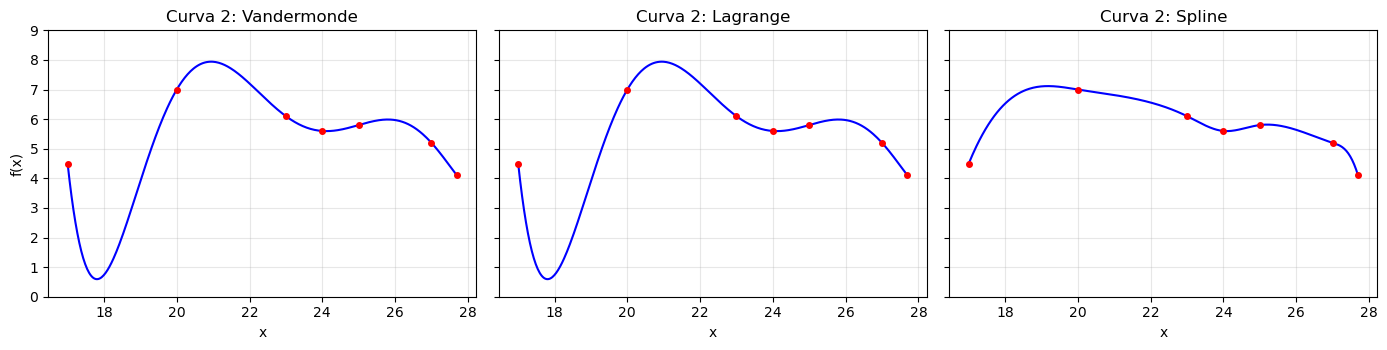

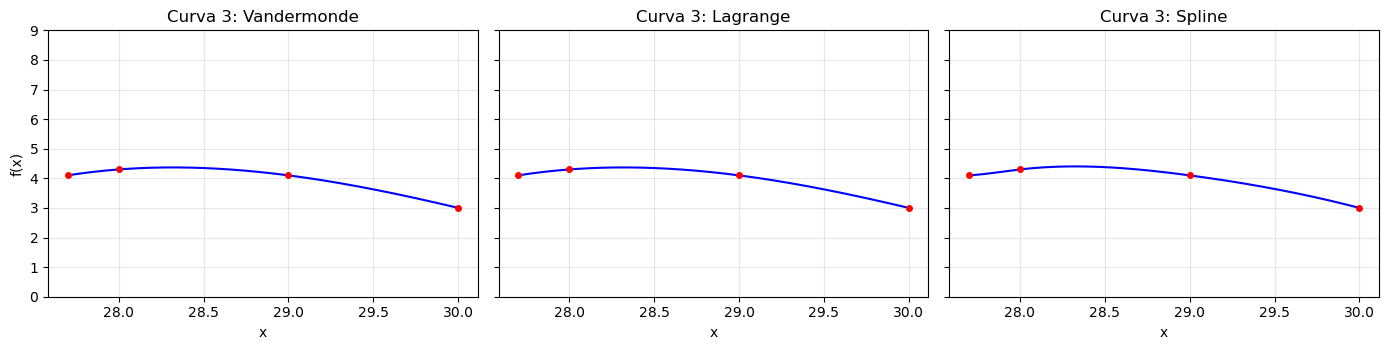

In [9]:
for k, d in enumerate(datos, start=1):
    fig, axs = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
    for ax, (m, funcs) in zip(axs, met.items()):
        ax.plot(d["t"], funcs[k - 1](d["t"]), "b-")
        ax.plot(d["x"], d["y"], "ro", ms=4)
        ax.set(title=f"Curva {k}: {m}", xlabel="x", ylim=YLIM)
        ax.grid(alpha=.3)
    axs[0].set_ylabel("f(x)")
    fig.tight_layout()
    if GUARDAR:
        fig.savefig(f"figuras/curva{k}.pdf")
    plt.show()

## 6. Silueta completa de Snoopy

Se unen las tres curvas interpoladas con el mismo método. El eje vertical se recorta entre 0 y 9, así que los valores del polinomio fuera de ese rango no se muestran.

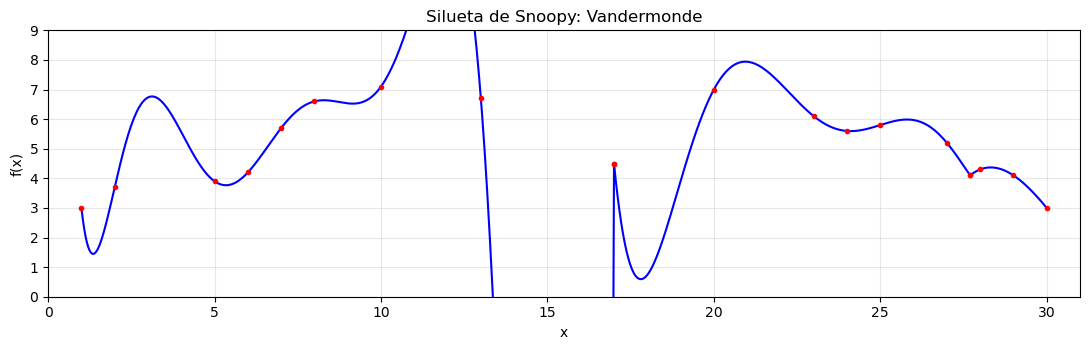

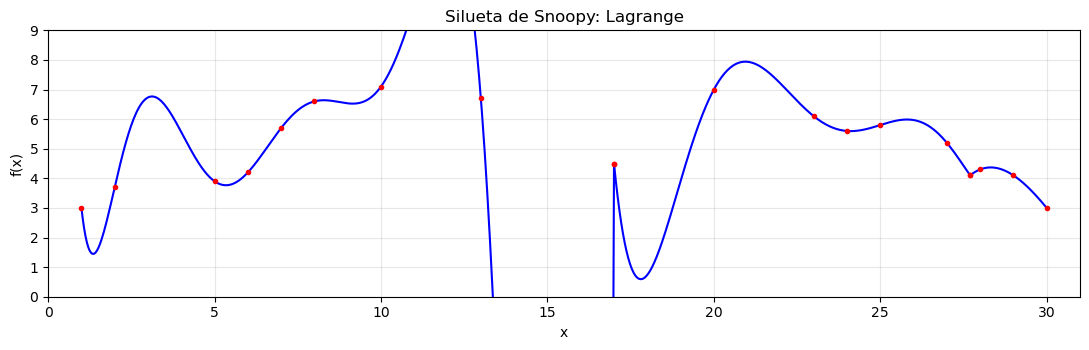

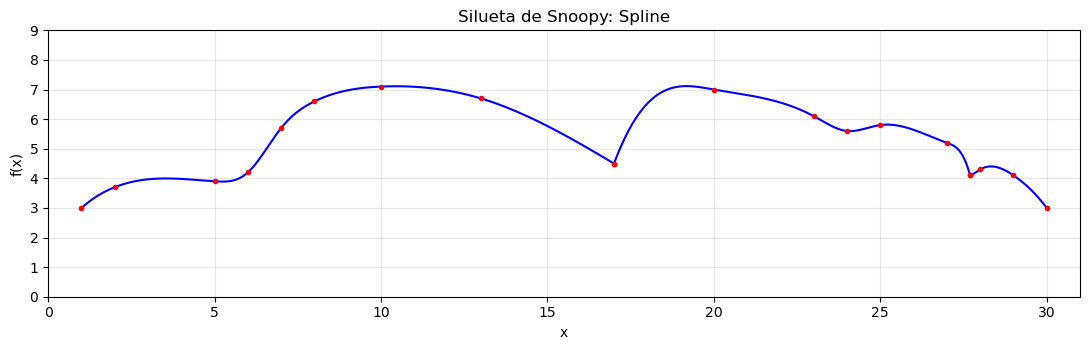

In [10]:
for m, funcs in met.items():
    fig, ax = plt.subplots(figsize=(11, 3.6))
    for d, f in zip(datos, funcs):
        ax.plot(d["t"], f(d["t"]), "b-")
        ax.plot(d["x"], d["y"], "ro", ms=3)
    ax.set(title=f"Silueta de Snoopy: {m}", xlabel="x", ylabel="f(x)",
           xlim=(0, 31), ylim=YLIM)
    ax.grid(alpha=.3)
    fig.tight_layout()
    if GUARDAR:
        fig.savefig(f"figuras/silueta_{m.lower()}.pdf")
    plt.show()

## Observaciones

- Vandermonde y Lagrange producen el mismo polinomio; la diferencia entre ambos es solo de redondeo, y crece con $\mathrm{cond}(V)$.
- Con 9 nodos (curva 1) los polinomios oscilan fuertemente entre nodos y se salen del rango de los datos; con 4 nodos (curva 3) se comportan bien.
- El spline cúbico sujeto se mantiene dentro del rango de los datos y respeta las pendientes de los extremos, por lo que es el único que reproduce bien la silueta.
- El spline programado coincide con `CubicSpline` de SciPy hasta el orden del redondeo.